In [4]:
import subprocess, sys, os

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])

os.environ.setdefault("KAGGLE_USERNAME", "your_kaggle_username")
os.environ.setdefault("KAGGLE_KEY", "your_kaggle_api_key")

import kaggle

dataset = "vibhingupta028/liver-histopathology-fibrosis-ultrasound-images"
output_dir = "./data"
os.makedirs(output_dir, exist_ok=True)

kaggle.api.authenticate()
kaggle.api.dataset_download_files(dataset, path=output_dir, unzip=True)

print("Dataset downloaded to", output_dir)

Dataset URL: https://www.kaggle.com/datasets/vibhingupta028/liver-histopathology-fibrosis-ultrasound-images


KeyboardInterrupt: 

Diagnoses (classes) found: ['F0', 'F1', 'F2', 'F3', 'F4']

Number of images per stage: {'F0': 2114, 'F1': 861, 'F2': 793, 'F3': 857, 'F4': 1698}


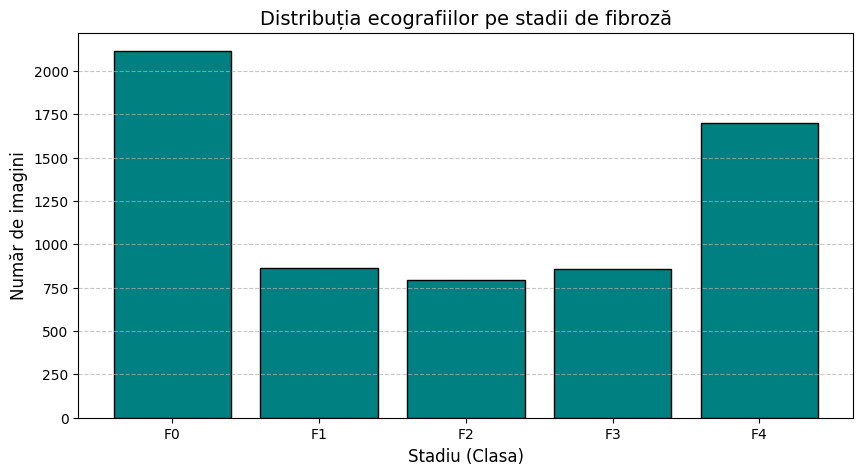

In [3]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

data_dir = './data' 

classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')]
classes.sort()

print(f"Diagnoses (classes) found: {classes}\n")

class_counts = {}
for c in classes:
    images = glob.glob(os.path.join(data_dir, c, '*.*'))
    class_counts[c] = len(images)

print(f"Number of images per stage: {class_counts}")

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='teal', edgecolor='black')
plt.title('Distribution of ultrasound images by fibrosis stage', fontsize=14)
plt.xlabel('Stage (Class)', fontsize=12)
plt.ylabel('Number of images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

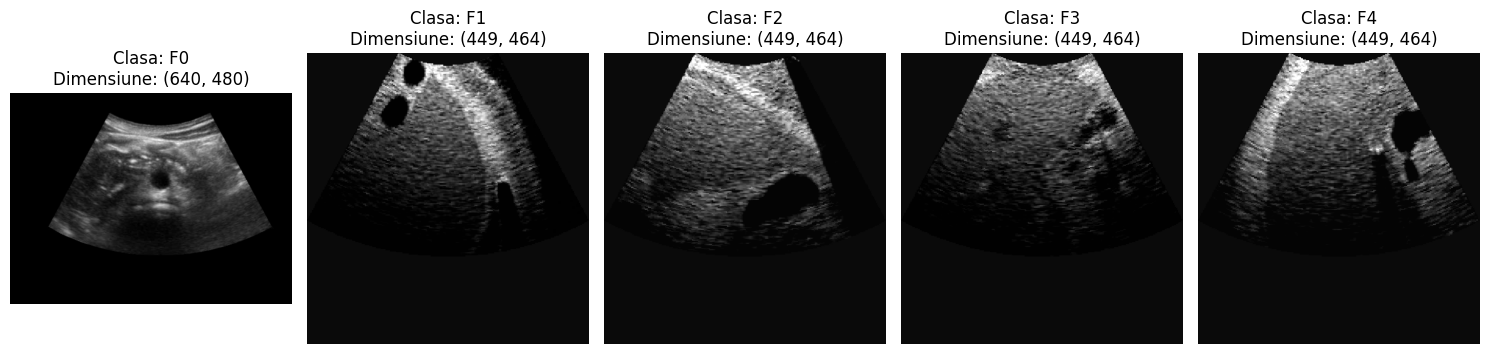

In [4]:
plt.figure(figsize=(15, 5))
for i, c in enumerate(classes):
    first_image_path = glob.glob(os.path.join(data_dir, c, '*.*'))[0]
    
    img = Image.open(first_image_path)
    
    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Class: {c}\nSize: {img.size}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [1]:
import splitfolders

original_data_dir = "./data" 

split_data_dir = "./dataset_split"

print("Starting the stratified split process...")

splitfolders.ratio(original_data_dir, 
                   output=split_data_dir, 
                   seed=42, 
                   ratio=(0.7, 0.15, 0.15), 
                   group_prefix=None)

print(f"Done! Check the folder: {split_data_dir}")


Starting the stratified split process...


Copying files: 6323 files [00:03, 1851.79 files/s]

Done! Check the folder: ./dataset_split


In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dir = 'dataset_split/train'
val_dir = 'dataset_split/val'
test_dir = 'dataset_split/test'

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

batch_size = 32

loader_train = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
loader_test = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(len(loader_train))
print(len(loader_val))
print(len(loader_test))

139
30
30


In [9]:
import torch.nn as nn
from torchvision import models

num_classes = len(train_dataset.classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_pretrained = models.resnet18(weights='DEFAULT')
num_features = model_pretrained.fc.in_features
model_pretrained.fc = nn.Linear(num_features, num_classes)
model_pretrained = model_pretrained.to(device)

model_scratch = models.resnet18(weights=None)
model_scratch.fc = nn.Linear(num_features, num_classes)
model_scratch = model_scratch.to(device)

print(f"Models configured on: {device}")
print(f"Number of classes: {num_classes}")

Models configured on: cuda
Number of classes: 5


In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer_pretrained = optim.Adam(model_pretrained.parameters(), lr=0.001)
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)

In [6]:
import time

def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = loader_train
            else:
                model.eval()
                dataloader = loader_val

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    time_elapsed = time.time() - since
    print(f'Training completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    return model

In [ ]:
print("Starting training of the PRETRAINED model:")
model_pretrained = train_model(model_pretrained, criterion, optimizer_pretrained, num_epochs=10)

Starting training of the PRETRAINED model:
Epoch 1/10
----------
train Loss: 0.8346 Acc: 0.6439
val Loss: 0.8787 Acc: 0.6152
Epoch 2/10
----------
train Loss: 0.6143 Acc: 0.7355
val Loss: 0.9810 Acc: 0.5455
Epoch 3/10
----------
train Loss: 0.5077 Acc: 0.7866
val Loss: 0.5478 Acc: 0.7548
Epoch 4/10
----------
train Loss: 0.4132 Acc: 0.8334
val Loss: 1.0725 Acc: 0.6723
Epoch 5/10
----------
train Loss: 0.3649 Acc: 0.8553
val Loss: 0.3732 Acc: 0.8636
Epoch 6/10
----------
train Loss: 0.3213 Acc: 0.8700
val Loss: 0.4087 Acc: 0.8510
Epoch 7/10
----------
train Loss: 0.2958 Acc: 0.8872
val Loss: 0.3596 Acc: 0.8615
Epoch 8/10
----------
train Loss: 0.2488 Acc: 0.9037
val Loss: 0.2930 Acc: 0.8922
Epoch 9/10
----------
train Loss: 0.3251 Acc: 0.8779
val Loss: 0.4401 Acc: 0.8457
Epoch 10/10
----------
train Loss: 0.2059 Acc: 0.9245
val Loss: 0.1896 Acc: 0.9292
Training completed in 6m 33s


In [8]:
torch.save(model_pretrained.state_dict(), 'model_fibroza_pretrained.pth')

In [9]:
model_scratch_trained = train_model(model_scratch, criterion, optimizer_scratch, num_epochs=10)

Epoch 1/10
----------
train Loss: 1.0180 Acc: 0.5593
val Loss: 53.4680 Acc: 0.1247
Epoch 2/10
----------
train Loss: 0.7642 Acc: 0.6751
val Loss: 2.5905 Acc: 0.3203
Epoch 3/10
----------
train Loss: 0.6382 Acc: 0.7248
val Loss: 18.1179 Acc: 0.1353
Epoch 4/10
----------
train Loss: 0.5460 Acc: 0.7653
val Loss: 0.8163 Acc: 0.6607
Epoch 5/10
----------
train Loss: 0.5216 Acc: 0.7762
val Loss: 1.0115 Acc: 0.6258
Epoch 6/10
----------
train Loss: 0.4404 Acc: 0.8117
val Loss: 1.0826 Acc: 0.6216
Epoch 7/10
----------
train Loss: 0.4279 Acc: 0.8261
val Loss: 0.4185 Acc: 0.8235
Epoch 8/10
----------
train Loss: 0.4105 Acc: 0.8327
val Loss: 0.5619 Acc: 0.7632
Epoch 9/10
----------
train Loss: 0.3333 Acc: 0.8689
val Loss: 0.4801 Acc: 0.8150
Epoch 10/10
----------
train Loss: 0.3032 Acc: 0.8754
val Loss: 0.2898 Acc: 0.8732
Training completed in 6m 23s


In [10]:
torch.save(model_scratch.state_dict(), 'model_fibroza_scratch.pth') 

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

import seaborn as sns

In [11]:
def evaluate_model(model, dataloader, device):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'accuracy': acc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'confusion_matrix': cm,
    }

In [12]:
num_classes = len(test_dataset.classes)
class_names = test_dataset.classes

model_pretrained_eval = models.resnet18(weights=None)
model_pretrained_eval.fc = nn.Linear(model_pretrained_eval.fc.in_features, num_classes)
model_pretrained_eval.load_state_dict(torch.load('model_fibroza_pretrained.pth', map_location=device))
model_pretrained_eval = model_pretrained_eval.to(device)

model_scratch_eval = models.resnet18(weights=None)
model_scratch_eval.fc = nn.Linear(model_scratch_eval.fc.in_features, num_classes)
model_scratch_eval.load_state_dict(torch.load('model_fibroza_scratch.pth', map_location=device))
model_scratch_eval = model_scratch_eval.to(device)

results_pretrained = evaluate_model(model_pretrained_eval, loader_test, device)
results_scratch = evaluate_model(model_scratch_eval, loader_test, device)

print('=== PRETRAINED: classification report (test) ===')
print(classification_report(results_pretrained['y_true'], results_pretrained['y_pred'], target_names=class_names, zero_division=0))

print('=== SCRATCH: classification report (test) ===')
print(classification_report(results_scratch['y_true'], results_scratch['y_pred'], target_names=class_names, zero_division=0))

/tmp/ipykernel_114361/248761953.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_pretrained_eval.load_state_dict(torch.load('model_fibroza_pretrained.pth', map_loca

/tmp/ipykernel_114361/248761953.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_pretrained_eval.load_state_dict(torch.load('model_fibroza_pretrained.pth', map_loca

=== PRETRAINED: classification report (test) ===
              precision    recall  f1-score   support

          F0       0.99      1.00      1.00       318
          F1       0.90      0.85      0.87       130
          F2       0.75      0.92      0.82       120
          F3       0.84      0.75      0.79       130
          F4       0.98      0.94      0.96       256

    accuracy                           0.92       954
   macro avg       0.89      0.89      0.89       954
weighted avg       0.92      0.92      0.92       954

=== SCRATCH: classification report (test) ===
              precision    recall  f1-score   support

          F0       0.99      0.99      0.99       318
          F1       0.66      0.85      0.75       130
          F2       0.78      0.58      0.67       120
          F3       0.75      0.84      0.79       130
          F4       0.96      0.88      0.92       256

    accuracy                           0.87       954
   macro avg       0.83      0.83   

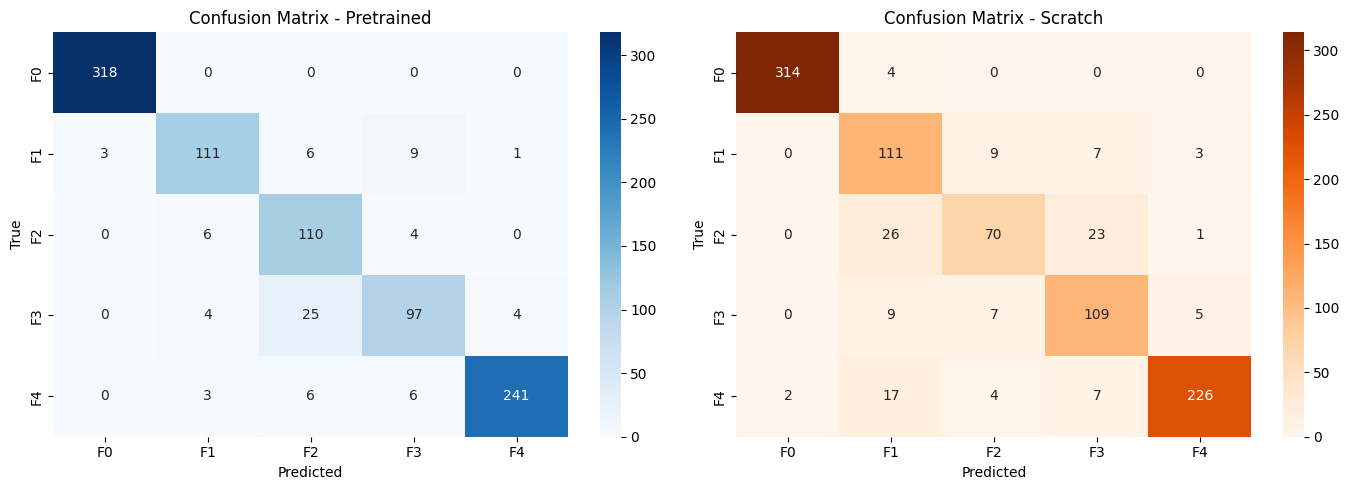

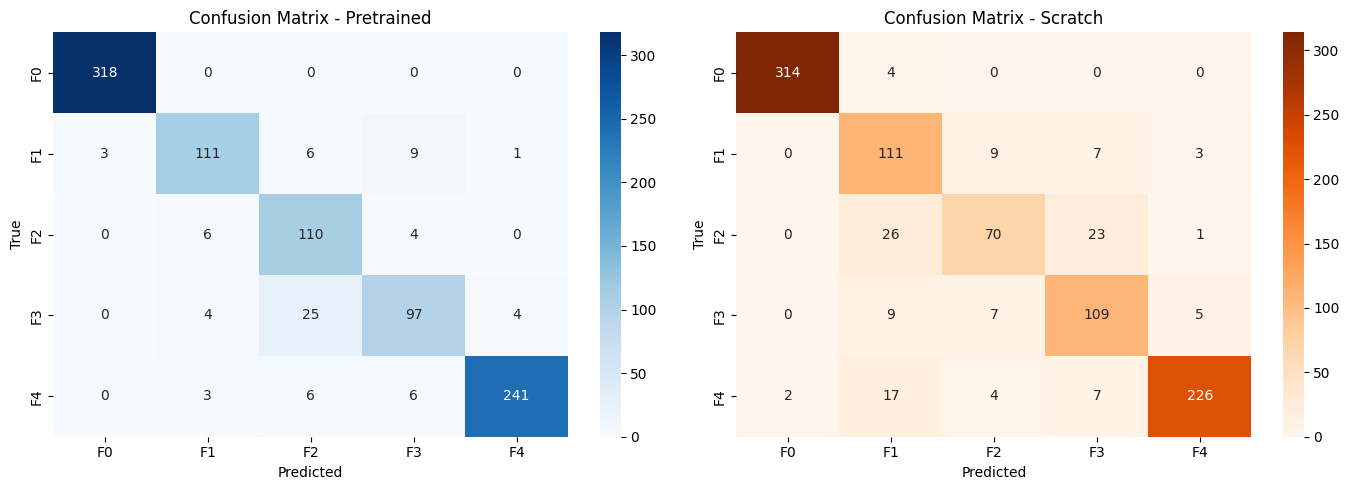

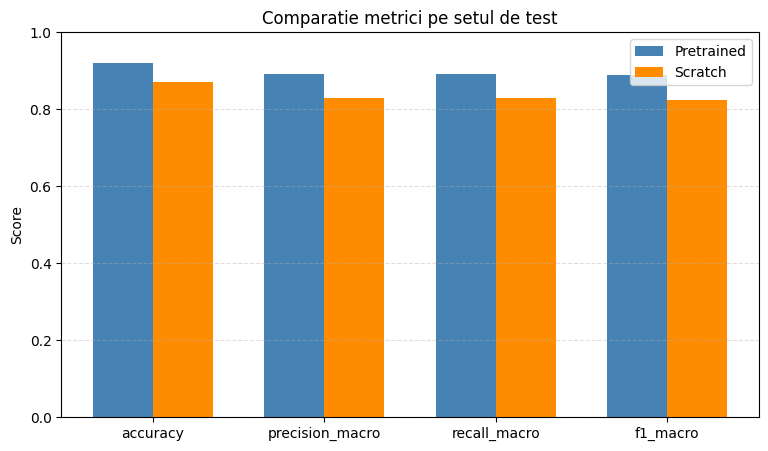

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    results_pretrained['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
)
axes[0].set_title('Confusion Matrix - Pretrained')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(
    results_scratch['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
)
axes[1].set_title('Confusion Matrix - Scratch')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
vals_pretrained = [results_pretrained[m] for m in metrics]
vals_scratch = [results_scratch[m] for m in metrics]

x = np.arange(len(metrics))
bar_width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - bar_width / 2, vals_pretrained, width=bar_width, label='Pretrained', color='steelblue')
plt.bar(x + bar_width / 2, vals_scratch, width=bar_width, label='Scratch', color='darkorange')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Metrics comparison on the test set')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()